
# Notebook 8 — `probes.ipynb`: what does each probe buy, one at a time?


| system | channels | question it answers |
|---|---|---|
| **E** | ethanol | the baseline: the soft sensor alone |
| **E+T** | ethanol + temperature | is the Pt100 worth it? |
| **E+pH** | ethanol + pH | is the pH electrode worth it? |
| **E+DO** | ethanol + dissolved O₂ | is the pO₂ spot worth it? |
| **E+all** | ethanol + T + pH + DO | the full rack (notebook 7's `E+P`) |

Each system is carried through **both** stages of the rig, because an instrument you have
paid for is available to the whole pipeline:

* **detection** — a bank of two-sided CUSUMs, one per channel of that system, first arm to
  cross raises the alarm;
* **isolation** — the MMAE bank scored on that system's channels only.

The physics, the plant, the shadow, the fault registry and the hypothesis bank are
**copied verbatim from `7_evaluation.ipynb`** (Part A below), so any difference in the
numbers is the measurement system and nothing else. The only structural change is in the
MMAE scorer: the probe likelihood is accumulated **per channel** instead of as one lumped
term, so a single set of replays scores all five systems at once.

**What comes out.** Three answers per fault: *did it alarm, how fast, and did the bank
then name the right cause* — for each probe on its own. That is the per-probe purchase
order.

---
# Part A — The rig (verbatim from `7_evaluation.ipynb`)

Physics, plant, shadow, CUSUM, fault registry and scenario set, unchanged. Skip to
Part B for what is new.

## A.1 · Imports

In [17]:
import copy
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120,
})
FIGDIR = Path('figures'); FIGDIR.mkdir(exist_ok=True)

# Two series throughout: the soft sensor alone, and the soft sensor + the rig's probes.
C_ETH, C_PRB = '#2a78d6', '#eb6834'      # validated categorical pair (blue / orange)
C_MUTED = '#52514e'

# Five systems, so the two-colour pair of notebook 7 is not enough. The baseline E is
# muted ink (it is the reference, not a series); the four instrumented systems take
# categorical slots 1-4 in fixed order. Validated: worst adjacent CVD dE 9.1, worst
# adjacent normal-vision dE 22.9. Two of the hues sit under 3:1 on white, so every bar
# in this notebook carries a direct value label and every figure has its table beside it.
C_SYS = {
    "E":     '#52514e',   # muted ink   - the soft sensor alone
    "E+T":   '#2a78d6',   # blue
    "E+pH":  '#eb6834',   # orange
    "E+DO":  '#1baf7a',   # aqua
    "E+all": '#eda100',   # yellow
}

## A.2 · Parameters

In [18]:
# ── A.2 · Parameters ─────────────────────────────────────────────────────────
# One dict, grouped as the app groups them. Every value is the deployed default
# (bioreactor_ui/backend/core.py :: DEFAULTS); nothing here is re-tuned for this
# notebook. The three that differ from notebook 7's own header are called out in
# Part H, because they are the whole reason the two artefacts print different
# numbers for the same physics.
PARAMS = {
    "kinetics": {
        "KG": 0.1, "KE": 0.1, "Ygx": 0.15, "Yge": 0.34, "Yex": 0.43,
        # Respiro-fermentative split (Crabtree). Oxygen does NOT scale the
        # growth rate; it sets the FATE of glucose carbon. A DO fault therefore
        # pushes ethanol UP while a T or pH fault pushes it DOWN, and that sign
        # is what tells them apart on an ethanol-only measurement.
        "YGE_FERM": 0.51, "YGX_OX": 0.25, "YGX_RED": 0.10,
        "C_RESP": 0.2573, "YO_E_REL": 2.0, "K_O2": 9.050,
    },
    "initial": {"X0": 2.5, "G0": 5.0, "E0": 0.0, "muG0": 0.15, "muE0": 0.08},
    "thermal": {
        "V": 1.35, "rhoCp": 4180.0, "Y_QX": 12000.0,
        "T_set": 30.0, "T_amb": 22.0, "UA": 18.0, "K_p": 50.0, "Q_max": 630.0,
        "T_min": 5.0, "T_opt": 30.0, "T_max": 40.0,      # 'robust' cardinals
    },
    "ph": {
        "pH_set": 5.0, "pH_min": 2.5, "pH_opt": 4.7, "pH_max": 8.0,
        "alpha_meta": 0.4, "alpha_pump": 0.2563,
        "F_A": 210.0, "F_B": 210.0,
        "Kc_pump": 120.0, "Ki_pump": 250.0, "DT_CTRL_s": 2.0,
    },
    "oxygen": {
        "N_rpm": 500.0, "Q_air_Lmin": 3.5, "DO_star": 100.0, "DO0": 100.0,
        "qO2_max": 8.0, "K_O": 3.0, "DO_sat_mgL": 6.7,
    },
    "ekf": {
        "sigma_E": 0.3162,        # what the FILTER assumes -> R = 0.1
        "sigma_E_sensor": 0.05,   # what the SENSOR actually does
        "cadence_min": 5.0, "cusum_k": 0.15, "cusum_h": 1.5,
        "sigma_T_probe": 0.1, "sigma_pH_probe": 0.02, "sigma_DO_probe": 1.0,
    },
    "sim": {"t_final": 10.0, "dt_min": 1.0},
}

# Quoted by the UI as a release gate on the root-cause panel; measured, not used,
# in this notebook. Part E is what measures them.
ETHANOL_SETTLE_MIN, PROBE_SETTLE_MIN = 80.0, 30.0
K_SLACK, H_CUSUM = PARAMS["ekf"]["cusum_k"], PARAMS["ekf"]["cusum_h"]

N_STATE = 8
IDX = {"T": 5, "pH": 6, "DO": 7}      # positions of T, pH, DO in the 8-state vector

print(f"batch {PARAMS['sim']['t_final']} h at {PARAMS['sim']['dt_min']} min/frame, "
      f"ethanol every {PARAMS['ekf']['cadence_min']} min")
print(f"deployed CUSUM  : k = {K_SLACK}  h = {H_CUSUM}   (units of sqrt(S))")
print(f"quoted constants: ETHANOL_SETTLE_MIN = {ETHANOL_SETTLE_MIN}"
      f"  PROBE_SETTLE_MIN = {PROBE_SETTLE_MIN}")

batch 10.0 h at 1.0 min/frame, ethanol every 5.0 min
deployed CUSUM  : k = 0.15  h = 1.5   (units of sqrt(S))
quoted constants: ETHANOL_SETTLE_MIN = 80.0  PROBE_SETTLE_MIN = 30.0


## A.3 · Growth modifiers, the carbon split, and kLa from the vessel

In [19]:
# ── A.3 · Growth modifiers, the carbon split, and kLa from the vessel ────────
PHI_FLOOR = 1e-6      # never return a hard zero: that hands the EKF a zero
                      # Jacobian and the filter can never correct its way back.


def _rosso_n2(v, v_min, v_opt, v_max):
    """Rosso (1993) CTMI, n = 2 — the cardinal TEMPERATURE model."""
    if v <= v_min or v >= v_max:
        return 0.0
    num = (v - v_max) * (v - v_min) ** 2
    den = (v_opt - v_min) * ((v_opt - v_min) * (v - v_opt)
                             - (v_opt - v_max) * (v_opt + v_min - 2 * v))
    return 0.0 if abs(den) < 1e-12 else num / den


def _rosso_n1(v, v_min, v_opt, v_max):
    """Rosso n = 1 — the pH form. No interior pole, asymmetric arms handled."""
    if v <= v_min or v >= v_max:
        return 0.0
    num = (v - v_min) * (v - v_max)
    den = num - (v - v_opt) ** 2
    return 0.0 if abs(den) < 1e-12 else num / den


def make_cardinal_modifier(v_min, v_opt, v_max, anchor, n=2):
    """Re-anchored Rosso modifier with f(anchor) == 1.

    Clipping happens AFTER re-anchoring and only from below: clipping to [0, 1]
    first would truncate the physically correct f > 1 that arises when the
    reactor sits nearer the optimum than the anchor does.

    `n` is about the SHAPE OF THE WINDOW, not about which variable it models.
    n = 2 is valid only while the optimum sits at or above the window midpoint;
    n = 1 is pole-free for any arms. A pole inside the window is invisible in the
    output — the clip presents it as a clean 0/1 step — which is exactly how
    f_pH once became a step function and made a stuck acid pump look like an
    oxygen crash. `_assert_monotone` below is the regression test.
    """
    raw = _rosso_n1 if n == 1 else _rosso_n2
    a = raw(anchor, v_min, v_opt, v_max)
    if a < 1e-9:
        raise ValueError(
            f"anchor {anchor} lies outside the viable window ({v_min}, {v_max}): "
            f"the modifier is normalised at the setpoint, so a setpoint the "
            f"organism cannot grow at leaves the HEALTHY reference dead.")
    return lambda v: max(raw(v, v_min, v_opt, v_max) / a, PHI_FLOOR)


def make_do_modifier(K_O, DO_star):
    """Re-anchored Monod oxygen limitation, f_DO(DO_star) == 1."""
    anchor = DO_star / (K_O + DO_star)

    def f_DO(DO):
        DO = max(DO, 0.0)
        return max(0.0, min(1.0, (DO / (K_O + DO)) / anchor))
    return f_DO


def absolute_modifier(v, v_min, v_opt, v_max, n=2):
    """The modifier relative to the organism's TRUE optimum, un-anchored.

    `make_cardinal_modifier` normalises at the SETPOINT, so f(setpoint) is
    identically 1 — useful for "how far from where we hold it", useless for "is
    where we hold it any good". This answers the second question.
    """
    raw = _rosso_n1 if n == 1 else _rosso_n2
    peak = raw(v_opt, v_min, v_opt, v_max)
    return 0.0 if peak < 1e-12 else raw(v, v_min, v_opt, v_max) / peak


def _assert_monotone(f, lo, hi, name, n=300):
    """Every modifier must rise monotonically towards its optimum."""
    step = (hi - lo) / (n - 1)
    prev = f(lo)
    for i in range(1, n):
        cur = f(lo + i * step)
        if cur - prev < -1e-9:
            raise ValueError(f"{name} is not monotone rising on [{lo}, {hi}]: a "
                             f"Rosso denominator has changed sign and the clip "
                             f"is hiding the pole as a step function.")
        prev = cur


def build_modifiers(p):
    """(f_T, f_pH, f_DO) for the current cardinals, with the shape guards."""
    th, ph, ox = p["thermal"], p["ph"], p["oxygen"]
    n_T = 2 if (th["T_opt"] - th["T_min"]) >= (th["T_max"] - th["T_opt"]) else 1
    f_T = make_cardinal_modifier(th["T_min"], th["T_opt"], th["T_max"],
                                 anchor=th["T_set"], n=n_T)
    # pH arms are asymmetric -> n = 1, anchored at the SETPOINT.
    f_pH = make_cardinal_modifier(ph["pH_min"], ph["pH_opt"], ph["pH_max"],
                                  anchor=ph["pH_set"], n=1)
    f_DO = make_do_modifier(ox["K_O"], ox["DO_star"])
    _assert_monotone(f_T, th["T_min"] + 1e-6, th["T_opt"], "f_T")
    _assert_monotone(f_pH, ph["pH_min"] + 1e-6, ph["pH_opt"], "f_pH")
    _assert_monotone(f_DO, 0.0, ox["DO_star"], "f_DO")
    return f_T, f_pH, f_DO


def carbon_fluxes(G, E, mu_max_G, mu_max_E, kin, phi_g=1.0, f_do=1.0):
    """Split glucose uptake between respiration and fermentation.

    Returns (q_ox, q_fm, mu_E, mu) per g X per h. The respiratory capacity is
    scaled by phi_g too: respiration is enzymatic, so cold or acid slows it
    exactly as it slows uptake. Leaving the cap at its 30 degC value made a
    chilled culture MORE respiratory — fermentation stopped, and ethanol, the
    only measurement, went silent on the very fault it had to see.
    """
    KG, KE, Ygx = kin["KG"], kin["KE"], kin["Ygx"]
    if mu_max_G > 1e-9:
        q_G = (mu_max_G * G / (KG + G) * phi_g) / Ygx
        suppression = 1.0 - (q_G * Ygx) / mu_max_G          # diauxic repression
    else:
        q_G, suppression = 0.0, 1.0
    q_ox = min(q_G, kin["C_RESP"] * phi_g * f_do)
    q_fm = q_G - q_ox                                       # overflow -> fermentation
    # ethanol is a RESPIRATORY substrate: no oxygen, no consumption
    mu_E = (mu_max_E * E / (KE + E) * suppression * phi_g * f_do
            ) if mu_max_E > 1e-9 else 0.0
    mu = q_ox * kin["YGX_OX"] + q_fm * kin["YGX_RED"] + mu_E
    return q_ox, q_fm, mu_E, mu


# ── kLa COMPUTED FROM THE VESSEL, not assumed ────────────────────────────────
# Van't Riet on the Minifors 2 geometry: kLa = C·(Pg/V)^a·v_s^b. Comes out at
# 44.8 1/h. Same function in 4_fault_injection, 7_mmae_fault_isolation and
# bioreactor_ui/backend/plant.py, so all four artefacts run one number.
_D_VESSEL_M, _D_IMP_FRAC, _N_POWER, _N_IMPELLERS = 0.090, 1 / 3, 5.0, 2
_RHO_BROTH, _PG_P0 = 1000.0, 0.5
_VR_C, _VR_A, _VR_B = 0.002, 0.7, 0.2


def compute_kLa(N_rpm, Q_air_Lmin, V_L):
    """Volumetric O2 transfer coefficient [1/h] from agitation + aeration."""
    A_cross = np.pi / 4.0 * _D_VESSEL_M ** 2
    D_imp = _D_VESSEL_M * _D_IMP_FRAC
    v_s = (Q_air_Lmin / 1000.0 / 60.0) / A_cross            # superficial gas vel [m/s]
    P0 = _N_IMPELLERS * _N_POWER * _RHO_BROTH * (N_rpm / 60.0) ** 3 * D_imp ** 5
    Pg_V = (_PG_P0 * P0) / (V_L / 1000.0)
    if Pg_V <= 0.0 or v_s <= 0.0:
        return 0.0
    return _VR_C * (Pg_V ** _VR_A) * (v_s ** _VR_B) * 3600.0


_fT, _fpH, _fDO = build_modifiers(PARAMS)
_kLa0 = compute_kLa(PARAMS["oxygen"]["N_rpm"], PARAMS["oxygen"]["Q_air_Lmin"],
                    PARAMS["thermal"]["V"])
_th = PARAMS["thermal"]
T_SS = ((_th["K_p"] * _th["T_set"] + _th["UA"] * _th["T_amb"])
        / (_th["K_p"] + _th["UA"]))
print(f"kLa (healthy, from geometry) = {_kLa0:.1f} 1/h")
print(f"thermal steady state         = {T_SS:.2f} degC   (NOT T_set: a P heater "
      f"needs a standing error)   f_T there = {_fT(T_SS):.3f}")
print(f"f_pH at the setpoint, absolute = "
      f"{absolute_modifier(5.0, 2.5, 4.7, 8.0, n=1):.3f}")

kLa (healthy, from geometry) = 44.8 1/h
thermal steady state         = 27.88 degC   (NOT T_set: a P heater needs a standing error)   f_T there = 0.974
f_pH at the setpoint, absolute = 0.988


## A.4 · Faults, and A.5 · the 8-state plant

In [20]:
# ── A.4 · The fault registry, and how a fault reaches the plant ──────────────
# Four actuator loops x two failure modes. A fault never edits a state: it
# changes the ACTUATOR CONTEXT of a control tick, and the ODE does the rest.
#
# AGITATION AND AERATION ARE ONE MECHANISM. Both reach the biology only through
# kLa, so any (rpm, air-flow) pair giving the same kLa produces a bit-identical
# trajectory in all 8 states — provably equal to 1e-9. They are one hypothesis
# parameterised two ways, and only an instrument on the actuator itself (a
# tachometer, an air mass-flow meter) could separate them. Severity is therefore
# a kLa RATIO, not an rpm.
FAULT_DEFAULTS = {
    "heater_off":         {"Q_pct": 0.0},        # % of heater power still delivered
    "heater_clog":        {"Q_pct": 6.0},
    "acid_pump_off":      {},                    # F_A forced to 0 (dead)
    "acid_pump_stuck":    {"F_A_stuck": 210.0},  # mL/h = pump saturation
    "base_pump_off":      {},                    # F_B forced to 0 (dead)
    "base_pump_stuck":    {"F_B_stuck": 210.0},
    "agitation_aer_stop": {"kla_pct": 0.0},      # % of healthy kLa still delivered
    "agitation_aer_clog": {"kla_pct": 3.0},
}


def normalize_fault(fault):
    """Fill a fault request with the defaults for its type."""
    fid = fault.get("fault") or fault.get("id")
    merged = dict(FAULT_DEFAULTS.get(fid, {}))
    merged.update({k: v for k, v in fault.items() if k not in ("fault", "id")})
    merged["fault"] = fid
    return merged


def apply_faults(active, t, p, base_F_A, base_F_B):
    """Resolve the actuator context at time t. Returns (F_A, F_B, heater_frac,
    UA_eff, kLa_eff)."""
    ox = p["oxygen"]
    F_A, F_B = base_F_A, base_F_B
    heater_frac, UA_eff = 1.0, p["thermal"]["UA"]
    kLa_eff = compute_kLa(ox["N_rpm"], ox["Q_air_Lmin"], p["thermal"]["V"])
    for f in active:
        if t < f.get("t_fault", 0.0):
            continue
        fid = f["fault"]
        if fid in ("heater_off", "heater_clog"):
            heater_frac = min(max(f.get("Q_pct", 0.0), 0.0), 100.0) / 100.0
        elif fid == "acid_pump_off":
            F_A = 0.0
        elif fid == "acid_pump_stuck":
            F_A = f.get("F_A_stuck", 210.0)
        elif fid == "base_pump_off":
            F_B = 0.0
        elif fid == "base_pump_stuck":
            F_B = f.get("F_B_stuck", 210.0)
        elif fid in ("agitation_aer_stop", "agitation_aer_clog"):
            kLa_eff *= min(max(f.get("kla_pct", 0.0), 0.0), 100.0) / 100.0
    return F_A, F_B, heater_frac, UA_eff, kLa_eff


# ── A.5 · The 8-state plant ──────────────────────────────────────────────────
def make_rhs(p, f_T, f_pH, f_DO, F_A, F_B, heater_frac, UA_eff, kLa_eff):
    """The 8-state RHS closure for ONE control tick, with the actuator context
    held fixed over it — which is what makes the discrete pH controller discrete.
    """
    kin, th, ph, ox = p["kinetics"], p["thermal"], p["ph"], p["oxygen"]
    Yex = kin["Yex"]
    V, rhoCp, Y_QX = th["V"], th["rhoCp"], th["Y_QX"]
    T_set, T_amb, K_p, Q_max = th["T_set"], th["T_amb"], th["K_p"], th["Q_max"]
    alpha_meta, alpha_pump = ph["alpha_meta"], ph["alpha_pump"]
    DO_star, DO_sat_mgL = ox["DO_star"], ox["DO_sat_mgL"]

    def rhs(t, y):
        X, G, E, m1, m2, T, pH, DO = y
        X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)
        pH = max(pH, 1.0); DO = max(DO, 0.0)

        phi_g = f_T(T) * f_pH(pH)          # RATE: temperature and pH only
        f_do = f_DO(DO)                    # FATE: oxygen caps respiration
        q_ox, q_fm, muE, mu = carbon_fluxes(G, E, m1, m2, kin, phi_g, f_do)
        q_Eox = muE / Yex                  # ethanol consumed [g E / g X / h]

        dX = mu * X
        dG = -(q_ox + q_fm) * X
        dE = (q_fm * kin["YGE_FERM"] - q_Eox) * X

        # Thermal ODE (W -> J/h via x3600; metabolic heat already J/h)
        Q_heat = heater_frac * max(0.0, min(Q_max, K_p * (T_set - T)))
        dT = (3600.0 * (Q_heat - UA_eff * (T - T_amb)) + Y_QX * mu * X * V) / (V * rhoCp)

        # pH ODE: yeast acidogenesis against the pump flows held for this tick
        dpH = -alpha_meta * mu * X + alpha_pump * F_B - alpha_pump * F_A
        if pH <= 1.0 and dpH < 0:
            dpH = 0.0

        # DO ODE (%-sat/h): OTR supply - respiratory OUR demand. Demand tracks
        # the OXIDATIVE flux only, so the fermentative branch draws no oxygen.
        demand = kin["K_O2"] * (q_ox + kin["YO_E_REL"] * q_Eox) * X
        dDO = kLa_eff * (DO_star - DO) - demand / DO_sat_mgL * 100.0
        if DO <= 0.0 and dDO < 0:
            dDO = 0.0
        return [dX, dG, dE, 0.0, 0.0, dT, dpH, dDO]
    return rhs


def _rk4(p, mods, y, t, dt, ctx):
    """One RK4 step with the actuator context `ctx` fixed."""
    rhs = make_rhs(p, *mods, *ctx)
    k1 = np.array(rhs(t, y))
    k2 = np.array(rhs(t + dt / 2, y + dt / 2 * k1))
    k3 = np.array(rhs(t + dt / 2, y + dt / 2 * k2))
    k4 = np.array(rhs(t + dt, y + dt * k3))
    y = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    y[0] = max(y[0], 0.0); y[1] = max(y[1], 0.0)
    y[2] = max(y[2], 0.0); y[7] = max(y[7], 0.0)
    return y


def advance(p, mods, y, t0, t1, faults, integ):
    """Integrate [t0, t1) with PI pH control on a short tick.

    The integral term is what slowly pushes pH back to the setpoint after a
    fault dips it; a pure-P law leaves a standing offset. Returns (y, integ) —
    the integral is carried per TRAJECTORY, so the healthy counterfactual and
    every MMAE hypothesis control themselves independently.
    """
    ph = p["ph"]
    pH_set, Kc, Ki = ph["pH_set"], ph["Kc_pump"], ph["Ki_pump"]
    F_A_max, F_B_max = ph["F_A"], ph["F_B"]
    dt_ctrl = max(ph["DT_CTRL_s"], 0.5) / 3600.0
    y = np.array(y, dtype=float)
    t = t0
    while t < t1 - 1e-12:
        h = min(dt_ctrl, t1 - t)
        err = pH_set - y[6]                       # >0 -> too acidic, add base
        u = Kc * err + Ki * integ                 # signed pump command [mL/h]
        if u >= 0.0:
            base_F_B, base_F_A = min(u, F_B_max), 0.0
        else:
            base_F_A, base_F_B = min(-u, F_A_max), 0.0
        # Anti-windup: do not accumulate while saturated and driving deeper in.
        saturated = u > F_B_max or u < -F_A_max
        if not (saturated and (err > 0.0) == (u > 0.0)):
            integ += err * h
        ctx = apply_faults(faults, t, p, base_F_A, base_F_B)
        y = _rk4(p, mods, y, t, h, ctx)
        t += h
    return y, integ


def rhs_for(p, mods, y, integ, faults, t):
    """The RHS in the actuator context state `y` implies at `t`.

    Same pump law and same fault resolution as `advance`, so the Jacobian is
    taken of exactly the dynamics the filter is propagated with. `faults=[]`
    gives the healthy shadow; an MMAE hypothesis passes its own list.
    """
    ph = p["ph"]
    u = ph["Kc_pump"] * (ph["pH_set"] - y[6]) + ph["Ki_pump"] * integ
    if u >= 0.0:
        F_B, F_A = min(u, ph["F_B"]), 0.0
    else:
        F_A, F_B = min(-u, ph["F_A"]), 0.0
    return make_rhs(p, *mods, *apply_faults(faults, t, p, F_A, F_B))

## A.6 · The healthy shadow and the CUSUM, and A.7 · one run of the rig

In [21]:
# ── A.6 · The Design-A healthy shadow and the CUSUM ──────────────────────────
# T, pH and DO are ESTIMATED states here, integrated from the HEALTHY ODEs and
# never fed in. That is the whole difference from Design B, where they are
# measured inputs folded into phi and the filter therefore FOLLOWS every fault.
# Because this filter only integrates healthy dynamics and is corrected by
# ethanol alone, it answers "how should this reactor be behaving?" — and the
# innovation is the fault signal.
P0 = np.diag([0.1, 0.02, 0.02, 1e-5, 1e-5, 1e-4, 1e-6, 1e-4])
Q8 = np.diag([1e-3, 1e-3, 1e-3, 1e-9, 1e-9, 1e-4, 1e-6, 1e-4])
Hm = np.zeros((1, N_STATE)); Hm[0, 2] = 1.0          # ethanol-only observation
# mumax is PINNED (1e-5 / 1e-9): the filter must not be able to absorb a fault
# by retuning the biology. A rigid reference is what keeps the fault visible.


def compute_jacobian(rhs, x, eps=1e-6):
    """Forward-difference Jacobian (8x8) of the healthy dynamics at x.

    Forward differences, not SymPy: the carbon split contains
    min(q_G, C_RESP*phi_g*f_do) and is not differentiable at the
    respiro-fermentative switch — exactly where a DO fault lives.
    """
    f0 = np.array(rhs(0.0, x), dtype=float)
    J = np.zeros((N_STATE, N_STATE))
    for j in range(N_STATE):
        xp = np.array(x, dtype=float)
        xp[j] += eps
        J[:, j] = (np.array(rhs(0.0, xp), dtype=float) - f0) / eps
    return J


class EKF8:
    """Continuous-discrete healthy-shadow EKF, stepped one frame at a time.

    State prediction does not live here: the caller advances this filter through
    the very same integrator that produces the healthy counterfactual, so "the
    EKF predicts with healthy dynamics" is true by construction rather than by a
    second copy of the ODEs that could drift out of sync.
    """

    def __init__(self, p):
        ini, th, ph, ox = p["initial"], p["thermal"], p["ph"], p["oxygen"]
        self.x = np.array([ini["X0"], ini["G0"], ini["E0"], ini["muG0"],
                           ini["muE0"], th["T_set"], ph["pH_set"], ox["DO0"]],
                          dtype=float)
        self.P = P0.copy()
        self.Q = Q8.copy()
        self.R = np.array([[max(p["ekf"]["sigma_E"] ** 2, 1e-4)]])
        self.I8 = np.eye(N_STATE)
        self.pi_int = 0.0            # the shadow runs its own pH controller
        self.prev_x = self.x.copy()

    def predict_cov(self, dt_h, rhs):
        """P <- Phi P Phi' + Q dt, with Phi = I + F dt at the current state."""
        Phi = self.I8 + compute_jacobian(rhs, self.x) * dt_h
        self.P = Phi @ self.P @ Phi.T + self.Q * dt_h

    def correct(self, z_ethanol):
        """Joseph-form update on ethanol. Returns (innovation, S)."""
        S = Hm @ self.P @ Hm.T + self.R
        K = self.P @ Hm.T @ np.linalg.inv(S)
        nu = float(z_ethanol - self.x[2])
        self.x = self.x + (K @ np.array([[nu]])).flatten()
        for i in (0, 1, 2, 7):
            self.x[i] = max(self.x[i], 0.0)
        self.x[6] = max(self.x[6], 1.0)
        # Batch mass balance, enforced on the CORRECTION. The plant has no death
        # term and no feed, so a correction that reverses either is inadmissible.
        # It matters because mumax is pinned: without this the filter absorbs the
        # fault into X and G instead, dragging X below the faulted truth and
        # CREATING glucose.
        self.x[0] = max(self.x[0], self.prev_x[0])
        self.x[1] = min(self.x[1], self.prev_x[1])
        IKH = self.I8 - K @ Hm
        self.P = IKH @ self.P @ IKH.T + K @ self.R @ K.T
        self.prev_x = self.x.copy()
        return nu, float(S[0, 0])


def cusum_step(sp, sn, z, k=K_SLACK, h=H_CUSUM):
    """ONE CUSUM update — the detector as it runs on the rig.

        S+ <- max(0, S+ + z - k)     ethanol ABOVE prediction
        S- <- max(0, S- - z - k)     ethanol BELOW prediction  <- fault direction

    `z` is the innovation normalised by the filter's own predicted spread
    sqrt(S), so a fixed threshold means the same thing at every step. Two floats
    of state, no history. The arms are NOT reset after firing: this study asks
    when a fault was FIRST seen, so they stay a monotone evidence trace.
    """
    sp = max(0.0, sp + z - k)
    sn = max(0.0, sn - z - k)
    return sp, sn, (sp > h or sn > h)


# ── A.7 · One run of the rig ─────────────────────────────────────────────────
class Simulation:
    """The plant, the healthy shadow and the detector, advanced frame by frame.

    Frame = 1 sim-minute, and each frame carries several PI control ticks. The
    same `advance` call produces the faulted trajectory, the no-fault
    counterfactual and the shadow's prediction — the only difference is the
    fault list handed to it.
    """

    def __init__(self, cfg=None):
        self.params = copy.deepcopy(PARAMS)
        for group, vals in (cfg or {}).items():
            self.params[group].update(vals)
        self.mods = build_modifiers(self.params)

        p = self.params
        ini, th, ph, ox = p["initial"], p["thermal"], p["ph"], p["oxygen"]
        self.y = np.array([ini["X0"], ini["G0"], ini["E0"], ini["muG0"],
                           ini["muE0"], th["T_set"], ph["pH_set"], ox["DO0"]],
                          dtype=float)
        self.healthy_y = self.y.copy()
        self.t, self.t_final = 0.0, p["sim"]["t_final"]
        self.dt_h = p["sim"]["dt_min"] / 60.0
        self.active_faults = []
        self.pi_int = self.pi_int_healthy = 0.0

        self.ekf = EKF8(p)
        self.sigma_E = p["ekf"]["sigma_E_sensor"]      # the REAL sensor noise
        self.cadence_h = p["ekf"]["cadence_min"] / 60.0
        self.next_meas_t = self.cadence_h
        self.rng = np.random.default_rng(0)

        self.cusum_k, self.cusum_h = p["ekf"]["cusum_k"], p["ekf"]["cusum_h"]
        self.sp = self.sn = 0.0
        self.alarm_t, self.alarm_idx = None, None
        self.rows, self.meas_rows, self.healthy_rows = [], [], []

    def inject_fault(self, fault):
        f = normalize_fault(fault)
        f["t_fault"] = float(f.get("t_fault", self.t))
        if f["t_fault"] < self.t - 1e-9:
            return False, "t_fault has already passed."
        self.active_faults.append(f)
        return True, f"{f['fault']} scheduled at t = {f['t_fault']:.2f} h."

    @property
    def done(self):
        return self.t >= self.t_final - 1e-9

    def advance(self, y, t0, t1, faults, integ):
        return advance(self.params, self.mods, y, t0, t1, faults, integ)

    def rhs_for(self, y, integ, faults, t):
        return rhs_for(self.params, self.mods, y, integ, faults, t)

    def step(self):
        t0, t1 = self.t, min(self.t + self.dt_h, self.t_final)
        self.y, self.pi_int = self.advance(self.y, t0, t1,
                                           self.active_faults, self.pi_int)
        self.healthy_y, self.pi_int_healthy = self.advance(
            self.healthy_y, t0, t1, [], self.pi_int_healthy)
        self.t = t1

        # Design A: predict with the HEALTHY dynamics — the same call that
        # produced the counterfactual above. Nothing about the faulted run enters
        # here; the ethanol correction below is the filter's only contact with
        # reality.
        e = self.ekf
        e.x, e.pi_int = self.advance(e.x, t0, t1, [], e.pi_int)
        e.predict_cov(t1 - t0, self.rhs_for(e.x, e.pi_int, [], t1))

        if self.t >= self.next_meas_t - 1e-9:
            z = self.y[2] + self.rng.normal(0.0, self.sigma_E)
            nu, S = e.correct(z)
            self.next_meas_t += self.cadence_h
            z_norm = nu / max(S ** 0.5, 1e-12)
            self.sp, self.sn, fired = cusum_step(self.sp, self.sn, z_norm,
                                                 self.cusum_k, self.cusum_h)
            self.meas_rows.append({"time_h": self.t, "frame": len(self.rows),
                                   "z": float(z), "nu": nu, "S": S,
                                   "Sp": self.sp, "Sn": self.sn})
            if fired and self.alarm_t is None:
                self.alarm_t = self.t
                self.alarm_idx = len(self.meas_rows) - 1

        X, G, E, _, _, T, pHv, DOv = self.y
        self.rows.append({"time_h": self.t, "T": float(T), "pH": float(pHv),
                          "DO": float(DOv), "G": float(G), "E": float(E),
                          "X": float(X)})
        hX, _, hE, _, _, hT, hpH, hDO = self.healthy_y
        self.healthy_rows.append({"time_h": self.t, "X": float(hX),
                                  "E": float(hE), "T": float(hT),
                                  "pH": float(hpH), "DO": float(hDO)})
        return self.rows[-1]

    def run(self):
        while not self.done:
            self.step()
        return self

## A.8 · The scenario set

In [22]:
T_FAULT = 0.5          # h — the app's own onset (backend/test_mmae_isolation.py), and the
                       # same for every scenario, so the delays below are comparable
CH = ("T", "pH", "DO") # the three probe channels

SCENARIOS = {
    "heater_off":         ({"Q_pct": 0.0},          "Heater dead"),
    "heater_clog":        ({"Q_pct": 6.0},          "Heater underpowered (6 % left)"),
    "acid_pump_off":      ({},                      "Acid pump dead"),
    "acid_pump_stuck":    ({"F_A_stuck": 210.0},    "Acid pump stuck ON"),
    "base_pump_off":      ({},                      "Base pump dead"),
    "base_pump_stuck":    ({"F_B_stuck": 210.0},    "Base pump stuck ON"),
    "agitation_aer_stop": ({"kla_pct": 0.0},        "Agitation/aeration stopped"),
    "agitation_aer_clog": ({"kla_pct": 3.0},        "Agitation/aeration restricted (3 % kLa)"),
}
LABEL = {k: v[1] for k, v in SCENARIOS.items()}
print(len(SCENARIOS), "scenarios, fault at t =", T_FAULT, "h")

8 scenarios, fault at t = 0.5 h


## A.9 · Running one batch, and reading the probes off it

In [23]:
def run_batch(fault_id=None, seed=0, t_fault=T_FAULT, cfg=None):
    """One batch. Returns (sim, P_diag_per_frame, shadow_state_per_frame)."""
    sim = Simulation(cfg)
    sim.rng = np.random.default_rng(seed)          # ethanol sensor noise stream
    if fault_id is not None:
        sim.inject_fault({"fault": fault_id, "t_fault": t_fault,
                          **SCENARIOS[fault_id][0]})
    Pd, xh = [], []
    while not sim.done:
        sim.step()
        Pd.append(np.diag(sim.ekf.P).copy())
        xh.append(sim.ekf.x.copy())
    return sim, np.array(Pd), np.array(xh)


def probe_channels(sim, Pd, xh, seed=0):
    """Noisy probe readings at the ethanol sample times, and their normalised
    innovations against the healthy shadow.

        nu_c = z_c - x_hat_c        S_c = P_cc + sigma_c^2        z = nu_c / sqrt(S_c)

    This is the Design-A logic verbatim, just on three more channels: the shadow
    never sees the probes, so the residual IS the fault signal.
    """
    rng = np.random.default_rng(10_000 + seed)
    sig = {c: sim.params["ekf"][f"sigma_{c}_probe"] for c in CH}
    z = {c: [] for c in CH}
    meas = {c: [] for c in CH}
    for m in sim.meas_rows:
        fr = m["frame"]
        for c in CH:
            zc = sim.rows[fr][c] + rng.normal(0.0, sig[c])
            S = Pd[fr][IDX[c]] + sig[c] ** 2
            meas[c].append(zc)
            z[c].append((zc - xh[fr][IDX[c]]) / np.sqrt(S))
    return ({c: np.array(v) for c, v in z.items()},
            {c: np.array(v) for c, v in meas.items()})


def ethanol_z(sim):
    """The normalised ethanol innovation the CUSUM actually consumes."""
    return np.array([m["nu"] / np.sqrt(m["S"]) for m in sim.meas_rows])


def sample_times(sim):
    return np.array([m["time_h"] for m in sim.meas_rows])


t0 = time.time()
_sim, _Pd, _xh = run_batch(None, seed=0)
print(f"healthy batch: {len(_sim.rows)} frames, {len(_sim.meas_rows)} ethanol samples, "
      f"{time.time()-t0:.1f} s")
print("alarm on a healthy batch:", _sim.alarm_t)

healthy batch: 600 frames, 120 ethanol samples, 1.1 s
alarm on a healthy batch: None


---
# Part B — Five measurement systems

## B.1 · The systems, and the detector

`cusum_bank` is notebook 7's, unchanged: independent two-sided CUSUMs, one per channel,
the first arm to cross wins. What changes is the channel list handed to it. The ethanol
arm keeps the deployed pair `(k, h) = (0.15, 1.5)`; the probe arms keep the σ-equivalent
`(1.0, 10.0)`. Nothing is re-tuned per probe — a threshold tuned per instrument would
make the comparison a tuning result rather than a measurement result.

In [24]:
# ── B.1 · The detector: a bank of independent two-sided CUSUMs ───────────────
K_PRB, H_PRB = 1.0, 10.0        # the sigma-equivalent of the deployed ethanol pair

SYSTEMS = {
    "ethanol": ("E",),          # E   — the soft sensor alone
    "probes":  ("E",) + CH,     # E+P — the soft sensor AND the rig's own instruments
}
SYS_LABEL = {"ethanol": "E · ethanol only", "probes": "E+P · ethanol + T/pH/DO"}


def cusum_bank(z, channels):
    """Independent two-sided CUSUMs, one per channel. Returns (alarm, arms).

    `alarm` is (sample index, channel) of the first arm to cross, or None.
    `arms` keeps the full (n, 2) trace per channel, because the onset walk-back
    needs the HISTORY of whichever arm fired, not merely the fact that it fired.
    """
    n = len(z["E"])
    arms = {c: np.zeros((n, 2)) for c in channels}
    state = {c: (0.0, 0.0) for c in channels}
    alarm = None
    for i in range(n):
        for c in channels:
            k, h = (K_SLACK, H_CUSUM) if c == "E" else (K_PRB, H_PRB)
            sp, sn, fired = cusum_step(state[c][0], state[c][1], z[c][i], k, h)
            state[c] = (sp, sn)
            arms[c][i] = (sp, sn)
            if fired and alarm is None:
                alarm = (i, c)
    return alarm, arms


def onset_from_arms(arm, idx, times):
    """Last sample time at which the FIRING arm was zero before the alarm.

    The same walk-back as `onset_estimate`, generalised off the ethanol arms
    stored inside `sim` onto whichever channel raised *this system's* alarm. The
    onset guess belongs to the detector, so each system owns its own — and the
    ladder in `run_mmae` is what absorbs the error either way.
    """
    key = 1 if arm[idx, 1] >= arm[idx, 0] else 0
    j = idx
    while j > 0 and arm[j - 1, key] > 0.0:
        j -= 1
    return float(times[j])

# The five systems. E is the baseline; the three single-probe systems are the per-probe
# purchase orders; E+all is notebook 7's E+P and the upper bound.
SYSTEMS = {
    "E":     ("E",),
    "E+T":   ("E", "T"),
    "E+pH":  ("E", "pH"),
    "E+DO":  ("E", "DO"),
    "E+all": ("E", "T", "pH", "DO"),
}
SYS_ORDER = list(SYSTEMS)
print(" | ".join(f"{s}: {'+'.join(c)}" for s, c in SYSTEMS.items()))

E: E | E+T: E+T | E+pH: E+pH | E+DO: E+DO | E+all: E+T+pH+DO


## B.2 · The MMAE bank, scored per channel

This is `run_mmae` from notebook 7 with one change, and it is worth stating precisely
because it is what makes five systems affordable.

Notebook 7 accumulates two likelihood channels in one replay: `ll["E"]` (ethanol) and
`ll["P"]` (T, pH and DO lumped together). Here the probe term is kept **per channel** —
`ll["T"]`, `ll["pH"]`, `ll["DO"]` — and a system's score is the sum of the channels it
owns:

```
score(E+pH) = Σ_k ll["E"][k] + Σ_k ll["pH"][k]
```

The **trajectories are identical** across systems: a hypothesis integrates the same ODEs
and is corrected by the same ethanol samples whatever probes are attached, because the
probes are monitors and are never fed back into the filter. Only the *likelihood* differs.
So one set of replays scores all five systems, and the cost of this notebook is notebook
7's cost, not 2.5× it.

The onset ladder, the profile-over-onset rule, the 2.3-nat tie margin and the null
hypothesis are untouched.

In [25]:
# ── B.2 · The MMAE bank: which fault, given the alarm ────────────────────────
# One EKF per candidate cause, every one fed the SAME recorded measurements, each
# believing its own fault started at its own onset. Verbatim from notebook 7
# except for the per-channel likelihood noted in the markdown above.
HYPOTHESIS_SEVERITY = {
    "heater_off":         {"Q_pct": 0.0},
    "heater_clog":        {"Q_pct": 6.0},
    "acid_pump_off":      {},
    "acid_pump_stuck":    {"F_A_stuck": 210.0},
    "base_pump_off":      {},
    "base_pump_stuck":    {"F_B_stuck": 210.0},
    "agitation_aer_stop": {"kla_pct": 0.0},
    "agitation_aer_clog": {"kla_pct": 3.0},
}
HYPOTHESIS_LABELS = {
    "heater_off": "Heater dead", "heater_clog": "Heater underpowered",
    "acid_pump_off": "Acid pump dead", "acid_pump_stuck": "Acid pump stuck ON",
    "base_pump_off": "Base pump dead", "base_pump_stuck": "Base pump stuck ON",
    "agitation_aer_stop": "Agitation/aeration stopped",
    "agitation_aer_clog": "Agitation/aeration restricted",
}
NULL = "healthy"      # the null hypothesis: nothing is wrong

# Onsets tried per cause, as offsets [h] from the CUSUM estimate. BACKWARDS ONLY:
# guessing early is nearly free (before its own onset a hypothesis simply IS the
# healthy model), guessing late is fatal. Depth goes to -120 min because the
# oxygen-loop faults alarm late. (7_mmae_fault_isolation.ipynb, C.2)
LADDER_H = (0.0, -0.5, -1.0, -1.5, -2.0)

TIE_MARGIN_NATS = 2.3       # 10:1 odds — below this, two causes are not distinguishable
DEGENERATE_NATS = 1e-6      # below this the two produced IDENTICAL innovations


def candidate_causes():
    return {fid: {"label": HYPOTHESIS_LABELS[fid],
                  "params": {**FAULT_DEFAULTS.get(fid, {}), **sev}}
            for fid, sev in HYPOTHESIS_SEVERITY.items()}


def onset_estimate(meas_rows, alarm_idx):
    """Last time the FIRING ethanol arm was zero before the alarm.

    The fallback used when no detector hands `run_mmae` an onset. Unreliable in
    BOTH directions, which is why the ladder exists.
    """
    i = alarm_idx
    key = "Sn" if meas_rows[i]["Sn"] >= meas_rows[i]["Sp"] else "Sp"
    j = i
    while j > 0 and meas_rows[j - 1][key] > 0.0:
        j -= 1
    return float(meas_rows[j]["time_h"])


class _Hyp:
    """A hypothesis filter: the shadow EKF plus the fault list it believes in."""

    def __init__(self, sim, faults):
        self.ekf, self.faults = EKF8(sim.params), faults

    def snapshot(self):
        e = self.ekf
        return {"x": e.x.copy(), "P": e.P.copy(),
                "prev_x": e.prev_x.copy(), "pi_int": e.pi_int}

    def restore(self, s):
        e = self.ekf
        e.x, e.P = s["x"].copy(), s["P"].copy()
        e.prev_x, e.pi_int = s["prev_x"].copy(), s["pi_int"]


def _new_ll(n):
    """One likelihood accumulator PER CHANNEL — the change from notebook 7."""
    return {c: np.zeros(n) for c in ("E",) + CH}


def _new_trace(n):
    return {k: np.zeros(n) for k in ("nu", "E", "T", "pH", "DO")}


def _replay(sim, hyp, grid, i0, i1, meas_by_frame, ll, tr, probes, snap_at=None):
    """Advance `hyp` over frames [i0, i1), accumulating one likelihood per channel.

    The Design-A step with the hypothesis' fault list in place of the empty one and
    the RECORDED ethanol sample in place of a fresh draw. The trajectory does not
    depend on which probes a system owns — the probes are monitors, never fed back —
    so ONE replay serves all five systems and they differ only in which of these
    channels they are allowed to add up.
    """
    e = hyp.ekf
    for i in range(i0, i1):
        if snap_at is not None and i in snap_at:
            snap_at[i].update(hyp.snapshot())
        t0 = grid[i - 1] if i > 0 else 0.0
        t1 = grid[i]
        e.x, e.pi_int = sim.advance(e.x, t0, t1, hyp.faults, e.pi_int)
        e.predict_cov(t1 - t0, sim.rhs_for(e.x, e.pi_int, hyp.faults, t1))
        m = meas_by_frame.get(i)
        if m is not None:
            k = m["k"]
            tr["E"][k] = e.x[2]
            tr["T"][k], tr["pH"][k], tr["DO"][k] = e.x[5], e.x[6], e.x[7]
            nu, S = e.correct(m["z"])
            tr["nu"][k] = nu
            ll["E"][k] = -0.5 * nu * nu / S - 0.5 * math.log(2.0 * math.pi * S)
            # Where the causes actually differ: a dead heater and a jammed acid pump
            # end in the same stalled ethanol curve, but at 22 degC vs 28 degC. Kept
            # per channel here, so the T term can be read without the pH and DO terms.
            for ch in CH:
                s = probes["sigma"][ch]
                d = probes[ch][k] - tr[ch][k]
                ll[ch][k] = -0.5 * d * d / (s * s) - 0.5 * math.log(2.0 * math.pi * s * s)
    if snap_at is not None and i1 in snap_at:
        snap_at[i1].update(hyp.snapshot())


def _score(names, runs, key):
    """Collapse one system's likelihood into a verdict: posterior, ties, margin."""
    totals = np.array([runs[c][key]["total"] for c in names])
    order = [int(j) for j in np.argsort(totals)[::-1]]
    p = np.exp(totals - totals.max()); p /= p.sum()      # uniform prior
    margin = float(totals[order[0]] - totals[order[1]]) if len(order) > 1 else None
    tied = [names[j] for j in order
            if totals[order[0]] - totals[j] < TIE_MARGIN_NATS]
    degenerate = [[a, b] for i, a in enumerate(names) for b in names[i + 1:]
                  if abs(runs[a][key]["total"] - runs[b][key]["total"]) < DEGENERATE_NATS]
    return {"verdict": names[order[0]], "tied": tied, "margin_nats": margin,
            "degenerate": degenerate, "order": [names[j] for j in order],
            "p": {c: float(p[j]) for j, c in enumerate(names)},
            "loglik": {c: float(totals[j]) for j, c in enumerate(names)},
            "onset": {c: runs[c][key]["onset"] for c in names}}


def run_mmae(sim, probe_meas=None, ladder_h=LADDER_H, n_frames=None, t_onset=None):
    """onset -> bank -> posterior -> verdict, ALL FIVE systems from one set of replays.

    `probe_meas` supplies NOISY probe readings; `n_frames` truncates the record, which
    is how Part C asks what the verdict would have been on less evidence; `t_onset` is
    the detector's onset guess, and it belongs to the caller because each system runs
    its own detector and therefore walks back its own arm.
    """
    if t_onset is None and sim.alarm_idx is None:
        return {"state": "no_alarm"}
    n_frames = len(sim.rows) if n_frames is None else min(n_frames, len(sim.rows))
    grid = [r["time_h"] for r in sim.rows[:n_frames]]
    meas = [m for m in sim.meas_rows if m["frame"] < n_frames]
    n = len(meas)
    if n == 0:
        return {"state": "no_alarm"}
    meas_by_frame = {m["frame"]: {"z": m["z"], "k": k} for k, m in enumerate(meas)}

    ek = sim.params["ekf"]
    probes = {"sigma": {c: ek[f"sigma_{c}_probe"] for c in CH}}
    for c in CH:
        probes[c] = np.array([(probe_meas[c][k] if probe_meas is not None
                               else sim.rows[m["frame"]][c])
                              for k, m in enumerate(meas)])

    t0_hat = (float(t_onset) if t_onset is not None
              else onset_estimate(sim.meas_rows, sim.alarm_idx))
    # Ladder onsets snapped DOWN to a frame boundary, so a hypothesis forks from the
    # shared healthy prefix exactly. Rungs landing on the same frame collapse.
    onsets, frames = [], []
    for off in ladder_h:
        t = max(0.0, t0_hat + off)
        fi = min(max(int(np.searchsorted(grid, t - 1e-12)), 0), n_frames - 1)
        if fi not in frames:
            frames.append(fi)
            onsets.append(grid[fi - 1] if fi > 0 else 0.0)

    # The null hypothesis IS the shared prefix: every faulted hypothesis is identical
    # to it until its own onset, so one pass gives both the null score and the forks.
    null = _Hyp(sim, [])
    ll_null = _new_ll(n)
    tr_null = _new_trace(n)
    snaps = {fi: {} for fi in frames}
    _replay(sim, null, grid, 0, n_frames, meas_by_frame, ll_null, tr_null,
            probes, snap_at=snaps)

    def _pack(label, onset, ll):
        """One entry per SYSTEM, each summing only the channels that system owns."""
        out = {"label": label,
               "channels": {c: float(ll[c].sum()) for c in ("E",) + CH}}
        for sysname, chans in SYSTEMS.items():
            tot = sum(ll[c] for c in chans)
            out[sysname] = {"onset": onset, "ll": tot, "total": float(tot.sum())}
        return out

    runs = {NULL: _pack("No fault (null)", None, ll_null)}
    for cid, meta in candidate_causes().items():
        best = None
        for fi, t_on in zip(frames, onsets):
            hyp = _Hyp(sim, [normalize_fault({"fault": cid, **meta["params"],
                                              "t_fault": t_on})])
            hyp.restore(snaps[fi])
            ll = {k: v.copy() for k, v in ll_null.items()}   # pre-onset = null
            tr = {k: v.copy() for k, v in tr_null.items()}
            _replay(sim, hyp, grid, fi, n_frames, meas_by_frame, ll, tr, probes)
            cand = _pack(meta["label"], t_on, ll)
            # PROFILE over the onset axis (max), never marginalise (sum): summing
            # rewards SLOW faults, which accumulate mass across rungs whatever is true.
            # Each system profiles independently — a probe can prefer a different rung.
            if best is None:
                best = cand
            else:
                for key in SYS_ORDER:
                    if cand[key]["total"] > best[key]["total"]:
                        best[key] = cand[key]
                # `channels` is the per-channel breakdown Part D reads, and a
                # breakdown only means anything on ONE trajectory — so it is
                # pinned to the rung the FULL system E+all profiles to, rather
                # than mixed across rungs chosen by different systems.
                if cand["E+all"]["total"] >= best["E+all"]["total"]:
                    best["channels"] = cand["channels"]
        runs[cid] = best

    names = list(runs)
    return {"state": "ok", "t_onset": t0_hat, "runs": runs,
            "scores": {s: _score(names, runs, s) for s in SYS_ORDER}}

### Consistency check

Two things must hold before any of the numbers below mean anything:

1. **E must reproduce notebook 7's `ethanol` scoring**, and **E+all its `probes` scoring** —
   summing the three probe channels separately and summing them together are the same
   number, so this is really a check that the refactor did not drop a term.
2. **The single-probe systems must sit between them**, since each adds a strict subset of
   the evidence E+all adds. (They need not be *ordered* among themselves — that is the
   question the notebook asks.)

In [26]:
_s, _Pd, _xh = run_batch("heater_off", seed=0)
_zp, _pm = probe_channels(_s, _Pd, _xh, seed=0)
_r = run_mmae(_s, probe_meas=_pm)
_runs = _r["runs"]

print("log-likelihood of the TRUE cause (heater_off), by system:")
for s in SYS_ORDER:
    print(f"  {s:6s} {_runs['heater_off'][s]['total']:14.1f}")

# The refactor check: E+all's total must equal the sum of its four channel totals
# (`channels` is pinned to E+all's own best rung, so this is the one exact identity;
# a single-probe system that profiled to a different rung legitimately differs).
_gap = max(abs(_runs[c]["E+all"]["total"] - sum(_runs[c]["channels"].values()))
           for c in _runs)
print(f"\nE+all total  ==  sum of its channel totals, worst gap: {_gap:.2e}")

print("\nverdicts on the full batch:")
for s in SYS_ORDER:
    sc = _r["scores"][s]
    print(f"  {s:6s} {sc['verdict']:20s} margin {sc['margin_nats']:10.1f} nats")

log-likelihood of the TRUE cause (heater_off), by system:
  E                23.5
  E+T           -2930.8
  E+pH            328.3
  E+DO           -135.2
  E+all         -2785.8

E+all total  ==  sum of its channel totals, worst gap: 5.82e-11

verdicts on the full batch:
  E      heater_off           margin        0.2 nats
  E+T    heater_off           margin     7008.4 nats
  E+pH   heater_off           margin        0.2 nats
  E+DO   heater_off           margin        0.4 nats
  E+all  heater_off           margin     7008.7 nats


---
# Part C — Every scenario, every system

`evaluate` runs **one** batch per scenario and reads it five ways. Per system:

* its own CUSUM bank fires → **alarm delay**, measured from the fault, and *which channel*
  crossed first;
* its own arm is walked back → its own onset guess `t̂₀`;
* the MMAE bank is re-scored over a ladder of evidence windows measured from **that
  system's own alarm**, each window truncating the record before the bank sees it, so no
  future information leaks back.

**Verdict delay is measured from the fault**, and it is the first window from which the
verdict is correct *and stays correct to the end of the batch*. A cause named right once
and then abandoned has not settled.

The replay cache is keyed by `(window, t̂₀)` and **shared across systems**, so two systems
that alarm at the same sample pay for the bank once.

> One batch per scenario, five systems, five windows each — **20-40 minutes**.

In [27]:
# ── C.1 · one scenario through all five systems ─────────────────────────────
OFFSETS_MIN = [0, 30, 60, 120, 180, 300]   # evidence windows from each system's own alarm
# Notebook 7's ladder, unchanged. Settle time is QUANTISED to these rungs, so a
# coarser ladder does not measure a slower system — it just falls through to the
# next rung it owns (dropping 180/300 moves ethanol on base_pump_stuck from 335
# to the end-of-batch window at 570, with identical alarm, verdict and margin).
# Keeping notebook 7's rungs is what makes the E column here comparable to its E.


def evaluate(fid, seed=0):
    """One batch, read by all five systems. Returns {system: row}, plus detail."""
    sim, Pd, xh = run_batch(fid, seed=seed)
    zp, pm = probe_channels(sim, Pd, xh, seed=seed)
    z = {"E": ethanol_z(sim), **zp}
    times, grid = sample_times(sim), [r["time_h"] for r in sim.rows]
    cache = {}                    # (n_frames, t_hat) -> all five systems' scores
    out, detail = {}, {}

    for sysname, chans in SYSTEMS.items():
        alarm, arms = cusum_bank(z, chans)
        if alarm is None:
            out[sysname] = {"alarm_min": np.nan, "alarm_ch": "-",
                            "verdict_min": np.nan, "verdict": "no alarm",
                            "margin": np.nan, "p_true": np.nan}
            detail[sysname] = pd.DataFrame()
            continue

        i, ch = alarm
        t_alarm = float(times[i])
        t_hat = onset_from_arms(arms[ch], i, times)

        rows = []
        for t in [t_alarm + o / 60.0 for o in OFFSETS_MIN] + [grid[-1]]:
            if t > grid[-1] + 1e-9:
                continue
            n = min(int(np.searchsorted(grid, t - 1e-9)) + 1, len(grid))
            key = (n, round(t_hat, 9))
            if key not in cache:
                cache[key] = run_mmae(sim, probe_meas=pm, n_frames=n,
                                      t_onset=t_hat)["scores"]
            s = cache[key][sysname]
            rows.append({"t_min": (grid[n - 1] - T_FAULT) * 60.0,   # from the FAULT
                         "verdict": s["verdict"], "ok": s["verdict"] == fid,
                         "margin": s["margin_nats"], "p_true": s["p"][fid]})

        tr = pd.DataFrame(rows).drop_duplicates(subset="t_min", keep="last")
        ok = tr.ok.to_numpy()
        if ok[-1]:                       # settled: correct from here to the end
            tail = np.flip(np.cumprod(np.flip(ok.astype(int))))
            settled = float(tr.t_min.to_numpy()[np.argmax(tail == 1)])
        else:
            settled = np.nan             # never settles inside the batch
        out[sysname] = {"alarm_min": (t_alarm - T_FAULT) * 60.0, "alarm_ch": ch,
                        "verdict_min": settled, "verdict": tr.verdict.iat[-1],
                        "margin": float(tr.margin.iat[-1]),
                        "p_true": float(tr.p_true.iat[-1])}
        detail[sysname] = tr
    return out, detail

In [28]:
t0 = time.time()
results, details = {}, {}
for fid in SCENARIOS:
    results[fid], details[fid] = evaluate(fid)
    line = "  ".join(f"{s}:{results[fid][s]['alarm_min']:>5.0f}m" for s in SYS_ORDER)
    print(f"{fid:22s} {line}   [{time.time()-t0:5.0f} s]")
print(f"\n{time.time()-t0:.0f} s total")

heater_off             E:   40m  E+T:    5m  E+pH:   40m  E+DO:   40m  E+all:    5m   [   52 s]
heater_clog            E:   45m  E+T:    5m  E+pH:   45m  E+DO:   45m  E+all:    5m   [  105 s]
acid_pump_off          E:  nanm  E+T:  nanm  E+pH:  nanm  E+DO:  nanm  E+all:  nanm   [  106 s]
acid_pump_stuck        E:   40m  E+T:   40m  E+pH:    5m  E+DO:   40m  E+all:    5m   [  159 s]
base_pump_off          E:  nanm  E+T:  nanm  E+pH:   40m  E+DO:  nanm  E+all:   40m   [  188 s]
base_pump_stuck        E:   35m  E+T:   35m  E+pH:    5m  E+DO:   35m  E+all:    5m   [  232 s]
agitation_aer_stop     E:   85m  E+T:   85m  E+pH:   85m  E+DO:   10m  E+all:   10m   [  308 s]
agitation_aer_clog     E:  185m  E+T:  185m  E+pH:  185m  E+DO:   10m  E+all:   10m   [  388 s]

388 s total


## C.2 · Alarm delay — how fast does each probe see it?

Minutes from the fault at t = 0.5 h to the first CUSUM arm crossing. `—` means the fault
never raised an alarm inside the 10 h batch on that system. The `ch` column is the channel
that actually crossed: it is the probe doing the work, and where it reads `E` the probe
attached to that system contributed nothing to detection.

In [29]:
alarm = pd.DataFrame({s: {LABEL[f]: results[f][s]["alarm_min"] for f in SCENARIOS}
                      for s in SYS_ORDER})
chan = pd.DataFrame({s: {LABEL[f]: results[f][s]["alarm_ch"] for f in SCENARIOS}
                     for s in SYS_ORDER})
alarm_tbl = pd.concat({s: pd.DataFrame({"min": alarm[s], "ch": chan[s]})
                       for s in SYS_ORDER}, axis=1)
print("alarm delay [min from the fault], and the channel that crossed\n")
alarm_tbl.round(0)

alarm delay [min from the fault], and the channel that crossed



E       E+T      E+pH      E+DO  \
                                           min ch    min ch    min  ch   min   
Heater dead                               40.0  E    5.0  T   40.0   E  40.0   
Heater underpowered (6 % left)            45.0  E    5.0  T   45.0   E  45.0   
Acid pump dead                             NaN  -    NaN  -    NaN   -   NaN   
Acid pump stuck ON                        40.0  E   40.0  E    5.0  pH  40.0   
Base pump dead                             NaN  -    NaN  -   40.0  pH   NaN   
Base pump stuck ON                        35.0  E   35.0  E    5.0  pH  35.0   
Agitation/aeration stopped                85.0  E   85.0  E   85.0   E  10.0   
Agitation/aeration restricted (3 % kLa)  185.0  E  185.0  E  185.0   E  10.0   

                                            E+all      
                                         ch   min  ch  
Heater dead                               E   5.0   T  
Heater underpowered (6 % left)            E   5.0   T  
Acid pump dead                            -   NaN   -  
Acid pump stuck ON                        E   5.0  pH  
Base pump dead                            -  40.0  pH  
Base pump stuck ON                        E   5.0  pH  
Agitation/aeration stopped               DO  10.0  DO  
Agitation/aeration restricted (3 % kLa)  DO  10.0  DO

In [30]:
print("detected (of %d scenarios), and mean delay over those\n" % len(SCENARIOS))
pd.DataFrame({
    s: {"scenarios detected": int(alarm[s].notna().sum()),
        "mean alarm delay [min]": alarm[s].mean(),
        "max alarm delay [min]":  alarm[s].max(),
        "alarms raised BY the probe": int((chan[s] != "E").sum())}
    for s in SYS_ORDER}).round(1)

detected (of 8 scenarios), and mean delay over those



,E,E+T,E+pH,E+DO,E+all
scenarios detected,6.0,6.0,7.0,6.0,7.0
mean alarm delay [min],71.7,59.2,57.9,30.0,11.4
max alarm delay [min],185.0,185.0,185.0,45.0,40.0
alarms raised BY the probe,2.0,4.0,4.0,4.0,8.0


## C.3 · Verdict — does the probe let the bank name the right cause?

`verdict` is what the MMAE bank names on the full batch; `settle` is the first evidence
window (minutes from the fault) from which the verdict is correct and stays correct;
`margin` is how far the winner beat the runner-up, in nats.

**Read the margin beside every verdict.** 2.3 nats is 10:1 odds — the bar below which two
causes are not distinguishable on this data. A correct verdict at 0.2 nats is the right
cause edging ahead, not an identification.

In [31]:
verdict = pd.DataFrame({
    s: {LABEL[f]: ("OK" if results[f][s]["verdict"] == f else results[f][s]["verdict"])
        for f in SCENARIOS} for s in SYS_ORDER})
settle = pd.DataFrame({s: {LABEL[f]: results[f][s]["verdict_min"] for f in SCENARIOS}
                       for s in SYS_ORDER})
margin = pd.DataFrame({s: {LABEL[f]: results[f][s]["margin"] for f in SCENARIOS}
                       for s in SYS_ORDER})
pd.concat({s: pd.DataFrame({"verdict": verdict[s], "settle": settle[s].round(0),
                            "margin": margin[s].round(1)})
           for s in SYS_ORDER}, axis=1)

E                     E+T  \
                                          verdict settle margin   verdict   
Heater dead                                    OK  160.0    0.2        OK   
Heater underpowered (6 % left)                 OK   45.0    0.3        OK   
Acid pump dead                           no alarm    NaN    NaN  no alarm   
Acid pump stuck ON                             OK  160.0    2.7        OK   
Base pump dead                           no alarm    NaN    NaN  no alarm   
Base pump stuck ON                             OK  335.0    0.0        OK   
Agitation/aeration stopped                     OK   85.0  105.2        OK   
Agitation/aeration restricted (3 % kLa)        OK  245.0    0.3        OK   

                                                            E+pH         \
                                        settle  margin   verdict settle   
Heater dead                                5.0  7537.5        OK  160.0   
Heater underpowered (6 % left)            35.0  6938.3        OK   45.0   
Acid pump dead                             NaN     NaN  no alarm    NaN   
Acid pump stuck ON                        40.0     3.7        OK    5.0   
Base pump dead                             NaN     NaN        OK   40.0   
Base pump stuck ON                       335.0     3.6        OK    5.0   
Agitation/aeration stopped                85.0   107.0        OK   85.0   
Agitation/aeration restricted (3 % kLa)  245.0     0.6        OK  185.0   

                                                       E+DO                   \
                                           margin   verdict settle    margin   
Heater dead                                   0.2        OK  100.0       0.4   
Heater underpowered (6 % left)                0.3        OK   75.0       0.5   
Acid pump dead                                NaN  no alarm    NaN       NaN   
Acid pump stuck ON                       289096.1        OK  160.0      10.9   
Base pump dead                            28573.3  no alarm    NaN       NaN   
Base pump stuck ON                       187693.9        OK  215.0       2.1   
Agitation/aeration stopped                  118.0        OK   10.0   27004.0   
Agitation/aeration restricted (3 % kLa)       0.2        OK   40.0  196531.3   

                                            E+all                   
                                          verdict settle    margin  
Heater dead                                    OK    5.0    7538.2  
Heater underpowered (6 % left)                 OK   35.0    6939.8  
Acid pump dead                           no alarm    NaN       NaN  
Acid pump stuck ON                             OK    5.0  289124.3  
Base pump dead                                 OK   40.0   28573.4  
Base pump stuck ON                             OK    5.0  187722.9  
Agitation/aeration stopped                     OK   10.0   27006.3  
Agitation/aeration restricted (3 % kLa)        OK   40.0  196531.9

In [32]:
print("isolation summary\n")
pd.DataFrame({
    s: {"verdict correct": int((verdict[s] == "OK").sum()),
        "of which identified (margin > 2.3)":
            int(((verdict[s] == "OK") & (margin[s] > TIE_MARGIN_NATS)).sum()),
        "settled inside the batch": int(settle[s].notna().sum()),
        "mean settle [min from fault]": settle[s].mean(),
        "median margin [nats]": margin[s].median()}
    for s in SYS_ORDER}).round(1)

isolation summary



,E,E+T,E+pH,E+DO,E+all
verdict correct,6.0,6.0,7.0,6.0,7.0
of which identified (margin > 2.3),2.0,5.0,4.0,3.0,7.0
settled inside the batch,6.0,6.0,7.0,6.0,7.0
mean settle [min from fault],171.7,124.2,75.0,100.0,20.0
median margin [nats],0.3,55.4,118.0,6.5,28573.4


---
# Part D — Reading it: which probe pays for which fault

## D.1 · Detection and isolation, side by side

Two panels, one row per fault, five bars per row. Left: minutes from the fault to the
alarm — **shorter is better**, and a bar that is missing entirely means that system never
alarmed. Right: minutes from the fault to a settled verdict, missing where the verdict
never settles. Every bar carries its number, because two of the five hues sit below the
3:1 contrast bar on white and the tables above are the authority either way.

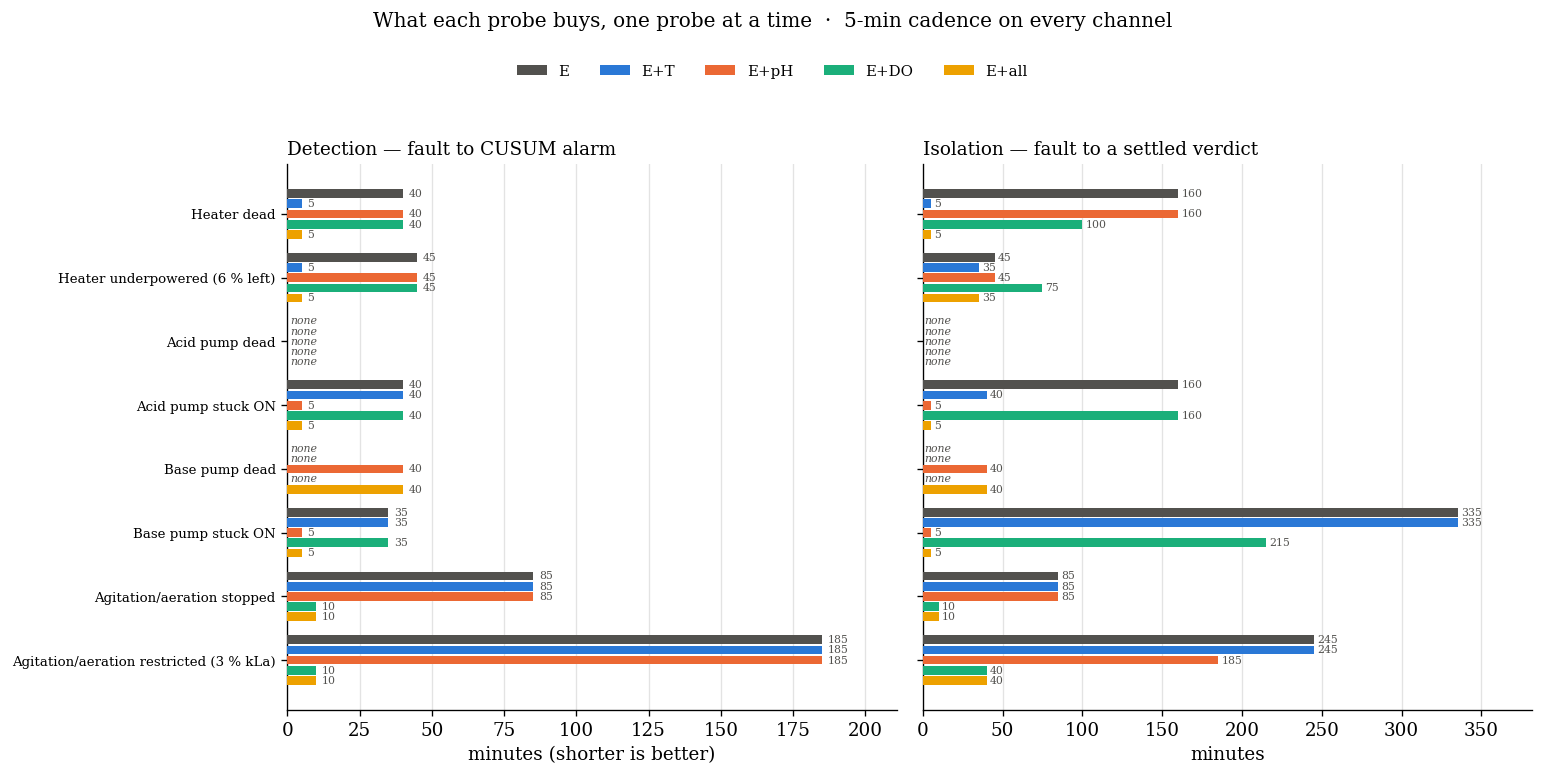

In [33]:
def _panel(ax, tbl, title, xlabel):
    faults = list(tbl.index)
    n_s = len(SYS_ORDER)
    h = 0.8 / n_s
    for j, s in enumerate(SYS_ORDER):
        y = np.arange(len(faults)) - 0.4 + h * (j + 0.5)
        v = tbl[s].to_numpy(dtype=float)
        ax.barh(y, np.nan_to_num(v), height=h * 0.86, color=C_SYS[s],
                label=s, zorder=3)
        for yi, vi in zip(y, v):
            if np.isnan(vi):
                ax.text(1, yi, "none", va='center', ha='left', fontsize=6.5,
                        color=C_MUTED, style='italic', zorder=4)
            else:
                ax.text(vi + 2, yi, f"{vi:.0f}", va='center', ha='left',
                        fontsize=6.5, color=C_MUTED, zorder=4)
    ax.set_yticks(np.arange(len(faults)))
    ax.set_yticklabels(faults, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left', fontsize=11)
    ax.grid(axis='y', visible=False)
    ax.margins(x=0.14)


fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)
_panel(axes[0], alarm, "Detection — fault to CUSUM alarm", "minutes (shorter is better)")
_panel(axes[1], settle, "Isolation — fault to a settled verdict", "minutes")
axes[0].invert_yaxis()          # once — the axis is SHARED, so twice cancels out
fig.legend(*axes[0].get_legend_handles_labels(), ncol=5, fontsize=9,
           loc='upper center', bbox_to_anchor=(0.5, 0.94), frameon=False)
fig.suptitle("What each probe buys, one probe at a time  ·  "
             "5-min cadence on every channel", fontsize=12, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIGDIR / "probes_alarm_and_verdict.png", dpi=200, bbox_inches='tight')
plt.show()

## D.2 · Where the isolation evidence actually comes from

The bars above say *whether* a probe helped. This says *why*: for each fault, the log-
likelihood the **true cause** earns from each channel, minus what the **runner-up** earns
from the same channel. Positive means that channel votes for the truth; near zero means it
is silent on this fault and the instrument is being paid for nothing.

It is a diverging quantity (votes for / votes against), so it gets a diverging encoding
with a neutral midpoint, and the numbers are printed in the cells — the sign matters more
than the shade, and `nats` spans orders of magnitude across faults.

In [34]:
# Full-batch scores per channel, true cause vs the runner-up under E+all.
rows = []
for fid in SCENARIOS:
    sim, Pd, xh = run_batch(fid, seed=0)
    zp, pm = probe_channels(sim, Pd, xh, seed=0)
    alarm_ep, arms_ep = cusum_bank({"E": ethanol_z(sim), **zp}, SYSTEMS["E+all"])
    t_hat = (onset_from_arms(arms_ep[alarm_ep[1]], alarm_ep[0], sample_times(sim))
             if alarm_ep is not None else T_FAULT)
    r = run_mmae(sim, probe_meas=pm, t_onset=t_hat)
    runs, order = r["runs"], r["scores"]["E+all"]["order"]
    rival = order[0] if order[0] != fid else order[1]     # best cause that is NOT the truth
    rows.append({"fault": LABEL[fid], "rival": HYPOTHESIS_LABELS.get(rival, rival),
                 **{ch: runs[fid]["channels"][ch] - runs[rival]["channels"][ch]
                    for ch in ("E",) + CH}})
    print(f"{fid:22s} rival {rival}")

evidence = pd.DataFrame(rows).set_index("fault")
evidence.round(1)

heater_off             rival heater_clog
heater_clog            rival heater_off
acid_pump_off          rival healthy
acid_pump_stuck        rival base_pump_off
base_pump_off          rival healthy
base_pump_stuck        rival acid_pump_off
agitation_aer_stop     rival agitation_aer_clog
agitation_aer_clog     rival agitation_aer_stop


,rival,E,T,pH,DO
fault,,,,,
Heater dead,Heater underpowered,0.2,7537.2,0.0,0.7
Heater underpowered (6 % left),Heater dead,0.2,6938.1,0.1,1.4
Acid pump dead,healthy,-0.0,-0.0,0.1,0.0
Acid pump stuck ON,Base pump dead,12.0,0.3,289084.2,27.9
Base pump dead,healthy,-0.0,-0.0,28573.4,0.1
Base pump stuck ON,Acid pump dead,4.2,0.2,187714.4,4.1
Agitation/aeration stopped,Agitation/aeration restricted,202.9,2.2,0.1,26801.0
Agitation/aeration restricted (3 % kLa),Agitation/aeration stopped,115.9,0.1,0.5,196415.4


In [ ]:
M = evidence[["E", "T", "pH", "DO"]].to_numpy(dtype=float)
# Symmetric log scaling: the values span ~7 decades and both signs, so a linear
# ramp would paint everything but one cell the midpoint colour.
Z = np.sign(M) * np.log10(1.0 + np.abs(M))
lim = np.abs(Z).max()

fig, ax = plt.subplots(figsize=(7.2, 4.4))
im = ax.imshow(Z, cmap='RdBu', vmin=-lim, vmax=lim, aspect='auto')   # +ve -> blue
ax.set_xticks(range(4)); ax.set_xticklabels(["ethanol", "T", "pH", "DO"])
ax.set_yticks(range(len(evidence))); ax.set_yticklabels(evidence.index, fontsize=8)
ax.set_title("Evidence for the true cause over its closest rival, per channel\n"
             "nats on the full batch  ·  blue = votes for the truth, red = against",
             loc='left', fontsize=10)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        txt = "0" if abs(v) < 0.05 else (f"{v:+.0f}" if abs(v) >= 1 else f"{v:+.1f}")
        ax.text(j, i, txt, ha='center', va='center', fontsize=7.5,
                color='white' if abs(Z[i, j]) > 0.6 * lim else '#1a1a19')
ax.grid(visible=False)
fig.tight_layout()
fig.savefig(FIGDIR / "probes_evidence_by_channel.png", dpi=200, bbox_inches='tight')
plt.show()

## D.3 · Saved outputs

In [ ]:
alarm.to_csv('data/probes_alarm_delay.csv')
settle.to_csv('data/probes_verdict_delay.csv')
margin.to_csv('data/probes_margin_nats.csv')
evidence.to_csv('data/probes_evidence_by_channel.csv')
print("wrote data/probes_{alarm_delay,verdict_delay,margin_nats,evidence_by_channel}.csv")
print("wrote figures/probes_{alarm_and_verdict,evidence_by_channel}.png")

---
## D.4 · What this notebook adds to notebook 7

Notebook 7 established that the probe rack as a whole is worth having. The per-probe
split is the decision an instrumentation budget actually faces, and it is not uniform:
each loop's fault is visible on the probe that sits in that loop, and the other two probes
are close to silent on it. The evidence map in D.2 is the direct statement of that — read
each row for which column is not near zero.

Two limits carried over unchanged from notebook 7, and neither is fixed by any probe:

* **`acid_pump_off` is state-identical to healthy.** A growing batch acidifies, so the PI
  controller only ever calls for base; a pump that is never asked to run cannot fail
  observably. No instrument at any price changes this.
* **The probes are monitors, never inputs.** Feeding a measured T/pH/DO back into the
  shadow would make the filter follow the fault and go blind on it — that is Design B, and
  notebook 6 measures it. Every gain reported here depends on the shadow staying healthy.

One batch and one noise seed per scenario, as in notebook 7's Part C: these are the
delays of a representative run, not a distribution over runs.